In [2]:
%load_ext autoreload
%autoreload 2

In [63]:
import logging
import multiprocessing
import os
import pickle
from functools import partial

logging.getLogger("pint").setLevel(logging.ERROR)

if os.environ.get("SLURM_CPUS_PER_TASK"):
    cores = int(os.environ.get("SLURM_CPUS_PER_TASK", 1))
else:
    cores = multiprocessing.cpu_count()
print(f"Number of cores: {cores}")

os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count={}".format(cores)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table
from gpjax.kernels import RBF, Linear, Matern12, Matern32, Matern52, Periodic, White
from jax import jit
from jaxoplanet import orbits
from jaxoplanet.light_curves import LimbDarkLightCurve
from jaxopt import ScipyMinimize
from tensorflow_probability.substrates.jax.distributions import Normal
from tqdm import tqdm

from gallifrey.inference import (
    calculate_whitened_residuals,
    log_likelihood_function,
    predictive_distribution,
)
from gallifrey.kernelsearch import KernelSearch, get_trainables, kernel_summary
from gallifrey.mcmc import nuts_warmup, run_mcmc
from gallifrey.visualisation import (
    plot_masks,
    plot_prediction,
    plot_residuals,
    plot_allan_deviation,
)

Number of cores: 8


In [4]:
jax.config.update("jax_enable_x64", True)
rng_key = jax.random.PRNGKey(42)

plt.style.use("../figures/gpjax.mplstyle")

mode = "load"

## LOAD DATA

In [5]:
model_name = "hats46b_gpmodel"

df = (
    Table.read("../data/external/HATS_46b.fit")
    .to_pandas()
    .drop(columns=["FWB20", "e_FWB20"])  # not used in paper
)

t = df["Time"].to_numpy()
t_min = np.amin(t)
t -= t_min

# spectroscopic and white light curves, initial entry is white lc
y = df.iloc[:, 1::2].to_numpy().T
yerr = df.iloc[:, 2::2].to_numpy().T

# mask out transit
mask = np.ones_like(t, dtype=bool)
mask[7:41] = False

# reference parameter and limb darkening parameter, first entry is white lc
reference = pd.read_csv("../data/external/HATS_46b_reference.csv").set_index(
    df.columns[1::2]
)

num_datasets = len(y)

## INDIVIDUAL KERNEL SEARCH FOR EVERY LIGHT CURVE

In [6]:
kernel_library = [
    Linear(),
    RBF(),
    Periodic(),
    White(),
    Matern12(),
    Matern32(),
    Matern52(),
]

In [7]:
gps = []
for i in range(num_datasets):
    if mode == "load":
        with open(
            f"../data/processed/observational_data/gp_models/hats46b/{model_name}_{i}",
            "rb",
        ) as file:
            gps.append(pickle.load(file))

    else:
        tree = KernelSearch(
            kernel_library,
            X=jnp.array(t[mask]),
            y=jnp.array(y[i][mask]),
            obs_stddev=jnp.amax(yerr[i][mask]),
            fit_obs_stddev=True,
            verbosity=0,
        )

        model = tree.search(
            depth=7,
            n_leafs=2,
            patience=0,
        ).posterior
        gps.append(model)

        if mode == "save":
            with open(
                f"../data/processed/observational_data/gp_models/hats46b/{model_name}_{i}",
                "wb",
            ) as file:
                pickle.dump(gps[i], file)
    print(f"Dataset {i}: {kernel_summary(gps[i], silence=True, short=True)}")

Dataset 0: Periodic
Dataset 1: Matérn12 + Linear
Dataset 2: Matérn12 • Matérn32
Dataset 3: Matérn52
Dataset 4: Matérn52
Dataset 5: RBF
Dataset 6: Periodic
Dataset 7: Matérn52
Dataset 8: Matérn12
Dataset 9: Matérn52
Dataset 10: RBF
Dataset 11: Matérn52
Dataset 12: Matérn52
Dataset 13: Matérn52
Dataset 14: Matérn52
Dataset 15: RBF
Dataset 16: RBF
Dataset 17: RBF
Dataset 18: RBF
Dataset 19: Matérn32
Dataset 20: RBF
Dataset 21: Periodic
Dataset 22: Periodic
Dataset 23: Matérn32
Dataset 24: RBF
Dataset 25: RBF


## DEFINE TRANSIT MODEL

In [8]:
def transit_model(
    t, transit_parameter, period=4.7423749, u2=None, global_transit_parameter=None
):
    globals_flag = False if global_transit_parameter is None else True

    if globals_flag:
        scaled_radius = transit_parameter[0]
        limb_darkening_coeff = [transit_parameter[1], u2]
        central_mass = global_transit_parameter[0]
        central_radius = global_transit_parameter[1]
        inclination = jnp.deg2rad(global_transit_parameter[2])
        time_transit = global_transit_parameter[3]
    else:
        scaled_radius = transit_parameter[0]
        limb_darkening_coeff = [transit_parameter[1], u2]
        central_mass = transit_parameter[2]
        central_radius = transit_parameter[3]
        inclination = jnp.deg2rad(transit_parameter[4])
        time_transit = transit_parameter[5]

    central = orbits.keplerian.Central(
        mass=central_mass,
        radius=central_radius,
    )

    orbit = orbits.keplerian.Body(
        central=central,
        period=period,
        radius=scaled_radius * central.radius,
        inclination=inclination,
        time_transit=time_transit,
    )

    lc = LimbDarkLightCurve(limb_darkening_coeff).light_curve(orbit, t=t)
    return lc

## FIT TRANSIT PARAMETER FOR WHITE LC

In [9]:
white_lc_log_likelihood = log_likelihood_function(
    gps[0],
    jit(partial(transit_model, u2=reference["u2"]["FWL"])),
    t,
    y[0],
    mask,
    fix_gp=False,
    compile=True,
    negative=True,
)
x0 = {
    "gp_parameter": get_trainables(gps[0], unconstrain=True),
    # planet radius, u1, host_star_mass, host_star_radius, inclination, time_transit
    "lc_parameter": jnp.array([0.09773, 0.547, 0.869, 0.894, 86.97, 0.075]),
}
white_lc_solve = ScipyMinimize(fun=white_lc_log_likelihood, method="l-bfgs-b").run(x0)
white_lc_parameter = white_lc_solve.params["lc_parameter"]

## DEFINE LIKELIHOOD, PRIOR, POSTERIOR

In [10]:
def get_logprob(gp_model, y, yerr, u1, u2, initial_position=None, fix_gp=False):
    gp_model = gp_model.likelihood.replace(obs_stddev=yerr) * gp_model.prior

    if initial_position is None:
        initial_position = {
            "gp_parameter": get_trainables(gp_model, unconstrain=True),
            "lc_parameter": jnp.array([0.12, u1]),
        }

    param_priors = {
        "gp_parameter": Normal(
            loc=initial_position["gp_parameter"],
            scale=0.2 * jnp.abs(initial_position["gp_parameter"]),
        ),
        "lc_parameter": Normal(
            loc=initial_position["lc_parameter"],
            scale=[0.2, 0.05],
        ),
    }

    # define light curve model
    lc_model = jit(
        partial(
            transit_model,
            u2=u2,
            global_transit_parameter=white_lc_parameter[2:],
        )
    )

    log_likelihood = log_likelihood_function(
        gp_model,
        lc_model,
        t,
        y,
        mask,
        fix_gp=fix_gp,
        compile=True,
    )

    @jit
    def log_priors(params):
        gp_log_priors = param_priors["gp_parameter"].log_prob(params["gp_parameter"])
        lc_log_priors = param_priors["lc_parameter"].log_prob(params["lc_parameter"])
        return jnp.sum(gp_log_priors) + jnp.sum(lc_log_priors)

    @jit
    def log_probability(params):
        return log_likelihood(params) + log_priors(params)

    return log_probability, initial_position

## PERFORM FITS

In [11]:
parameter_solutions = []
for i in tqdm(range(num_datasets)):
    log_probability, initial_position = get_logprob(
        gps[i],
        y[i],
        jnp.amax(yerr[i]),
        reference["u1"].iloc[i],
        reference["u2"].iloc[i],
    )
    solve = ScipyMinimize(
        fun=jit(lambda par: -log_probability(par)),
        method="l-bfgs-b",
    ).run(initial_position)
    parameter_solutions.append(solve.params)

  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [01:35<00:00,  3.68s/it]


## RUN MCMC

In [12]:
num_adapt = 200
num_samples = 100
num_chains = cores

fix_gp = False

In [13]:
chains = {"gp_parameter": [], "lc_parameter": []}

for i in tqdm(range(num_datasets)):
    if mode == "load":
        chain = np.load(
            f"../data/processed/observational_data/mcmc_chains/{model_name}_{i}_parameter.npz",
        )
        chains["gp_parameter"].append(chain["gp_parameter"])
        chains["lc_parameter"].append(chain["lc_parameter"])

    else:
        log_probability, initial_position = get_logprob(
            gps[i],
            y[i],
            jnp.amax(yerr[i]),
            reference["u1"].iloc[i],
            reference["u2"].iloc[i],
            initial_position=parameter_solutions[i],
            fix_gp=fix_gp,
        )

        # run nuts adaption
        rng_key, warmup_key = jax.random.split(rng_key, 2)
        state, parameters = nuts_warmup(
            warmup_key,
            log_probability,
            initial_position,
            num_steps=num_adapt,
            progress_bar=False,
        )

        # define initial positions and add scatter
        initial_positions = {}
        for key, value in initial_position.items():
            rng_key, scatter_key = jax.random.split(rng_key)
            initial_positions[key] = jnp.tile(
                value, (num_chains, 1)
            ) + 0.05 * value * jax.random.normal(
                scatter_key, shape=(num_chains, value.size)
            )

        rng_key, sample_key = jax.random.split(rng_key, 2)

        final_state, state_history, info_history = run_mcmc(
            sample_key,
            log_probability,
            parameters,
            initial_positions,
            num_steps=num_samples,
        )

        for par in ["gp_parameter", "lc_parameter"]:
            chain = np.array(state_history.position[par])
            chains[par].append(chain)

        if mode == "save":
            np.savez(
                f"../data/processed/observational_data/mcmc_chains/{model_name}_{i}_parameter.npz",
                **{key: chains[key][i] for key in chains.keys()},
            )

  0%|          | 0/26 [00:00<?, ?it/s]

100%|██████████| 26/26 [00:00<00:00, 820.58it/s]


## ANALYSIS

### PLOT SPECTRUM

In [14]:
Rp_fit = np.array([sol["lc_parameter"][0] for sol in parameter_solutions])
Rp_percentiles = np.percentile(
    np.array(chains["lc_parameter"]).reshape(26, num_samples * num_chains, 2),
    [16, 84],
    axis=1,
)[:, :, 0]
errorbars = np.array([Rp_fit - Rp_percentiles[0], Rp_percentiles[1] - Rp_fit])

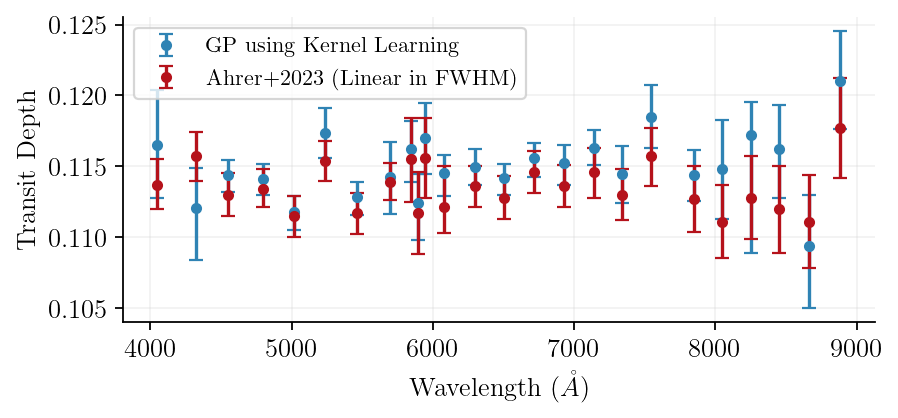

In [78]:
fig, ax = plt.subplots()

ax.errorbar(
    reference["wavelength"].iloc[1:],
    Rp_fit[1:],
    yerr=errorbars[:, 1:],
    fmt=".",
    capsize=3,
    label="GP using Kernel Learning",
)

ax.errorbar(
    reference["wavelength"].iloc[1:],
    reference["Rp"][1:],
    yerr=reference[["e_Rp_lower", "e_Rp_upper"]][1:].T,
    fmt=".",
    capsize=3,
    label="Ahrer+2023 (Linear in FWHM)",
)

ax.legend()
ax.set_xlabel(r"Wavelength ($\mathring{A}$)")
ax.set_ylabel("Transit Depth")
fig.savefig("../figures/006_HATS46b/spectrum.pdf")

### LIGHT CURVES

In [16]:
rng_key, sample_key = jax.random.split(rng_key)

parameter_sample = lambda key, num: jax.random.choice(key, len(chains), shape=(num,))

samples_with_transit = {}
samples_without_transit = {}
residuals = {}
for i in tqdm(range(num_datasets)):
    samples_with_transit[i] = []
    samples_without_transit[i] = []
    residuals[i] = []

    for idx in parameter_sample(sample_key, 100):
        rng_key, sample_key = jax.random.split(rng_key)

        lc_parameter = chains["lc_parameter"][i].reshape(num_chains * num_samples, -1)
        gp_parameter = chains["gp_parameter"][i].reshape(num_chains * num_samples, -1)

        transit = partial(
            transit_model,
            u2=reference["u2"].iloc[i],
            global_transit_parameter=white_lc_parameter[2:],
        )

        dist = predictive_distribution(
            gps[i],
            t,
            x=jnp.array(t[mask]),
            y=jnp.array(y[i][mask]),
            transit_model=transit,
            transit_parameter=lc_parameter[idx],
            gp_parameter=gp_parameter[idx],
        )
        sample = dist.sample(seed=sample_key)

        samples_with_transit[i].append(sample)
        samples_without_transit[i].append(sample - transit(t, lc_parameter[idx]))
        residuals[i].append(calculate_whitened_residuals(y[i], dist))
        del dist

residuals_std = [(jnp.array(residuals[i]) ** 2).mean() for i in residuals.keys()]

100%|██████████| 26/26 [09:07<00:00, 21.04s/it]


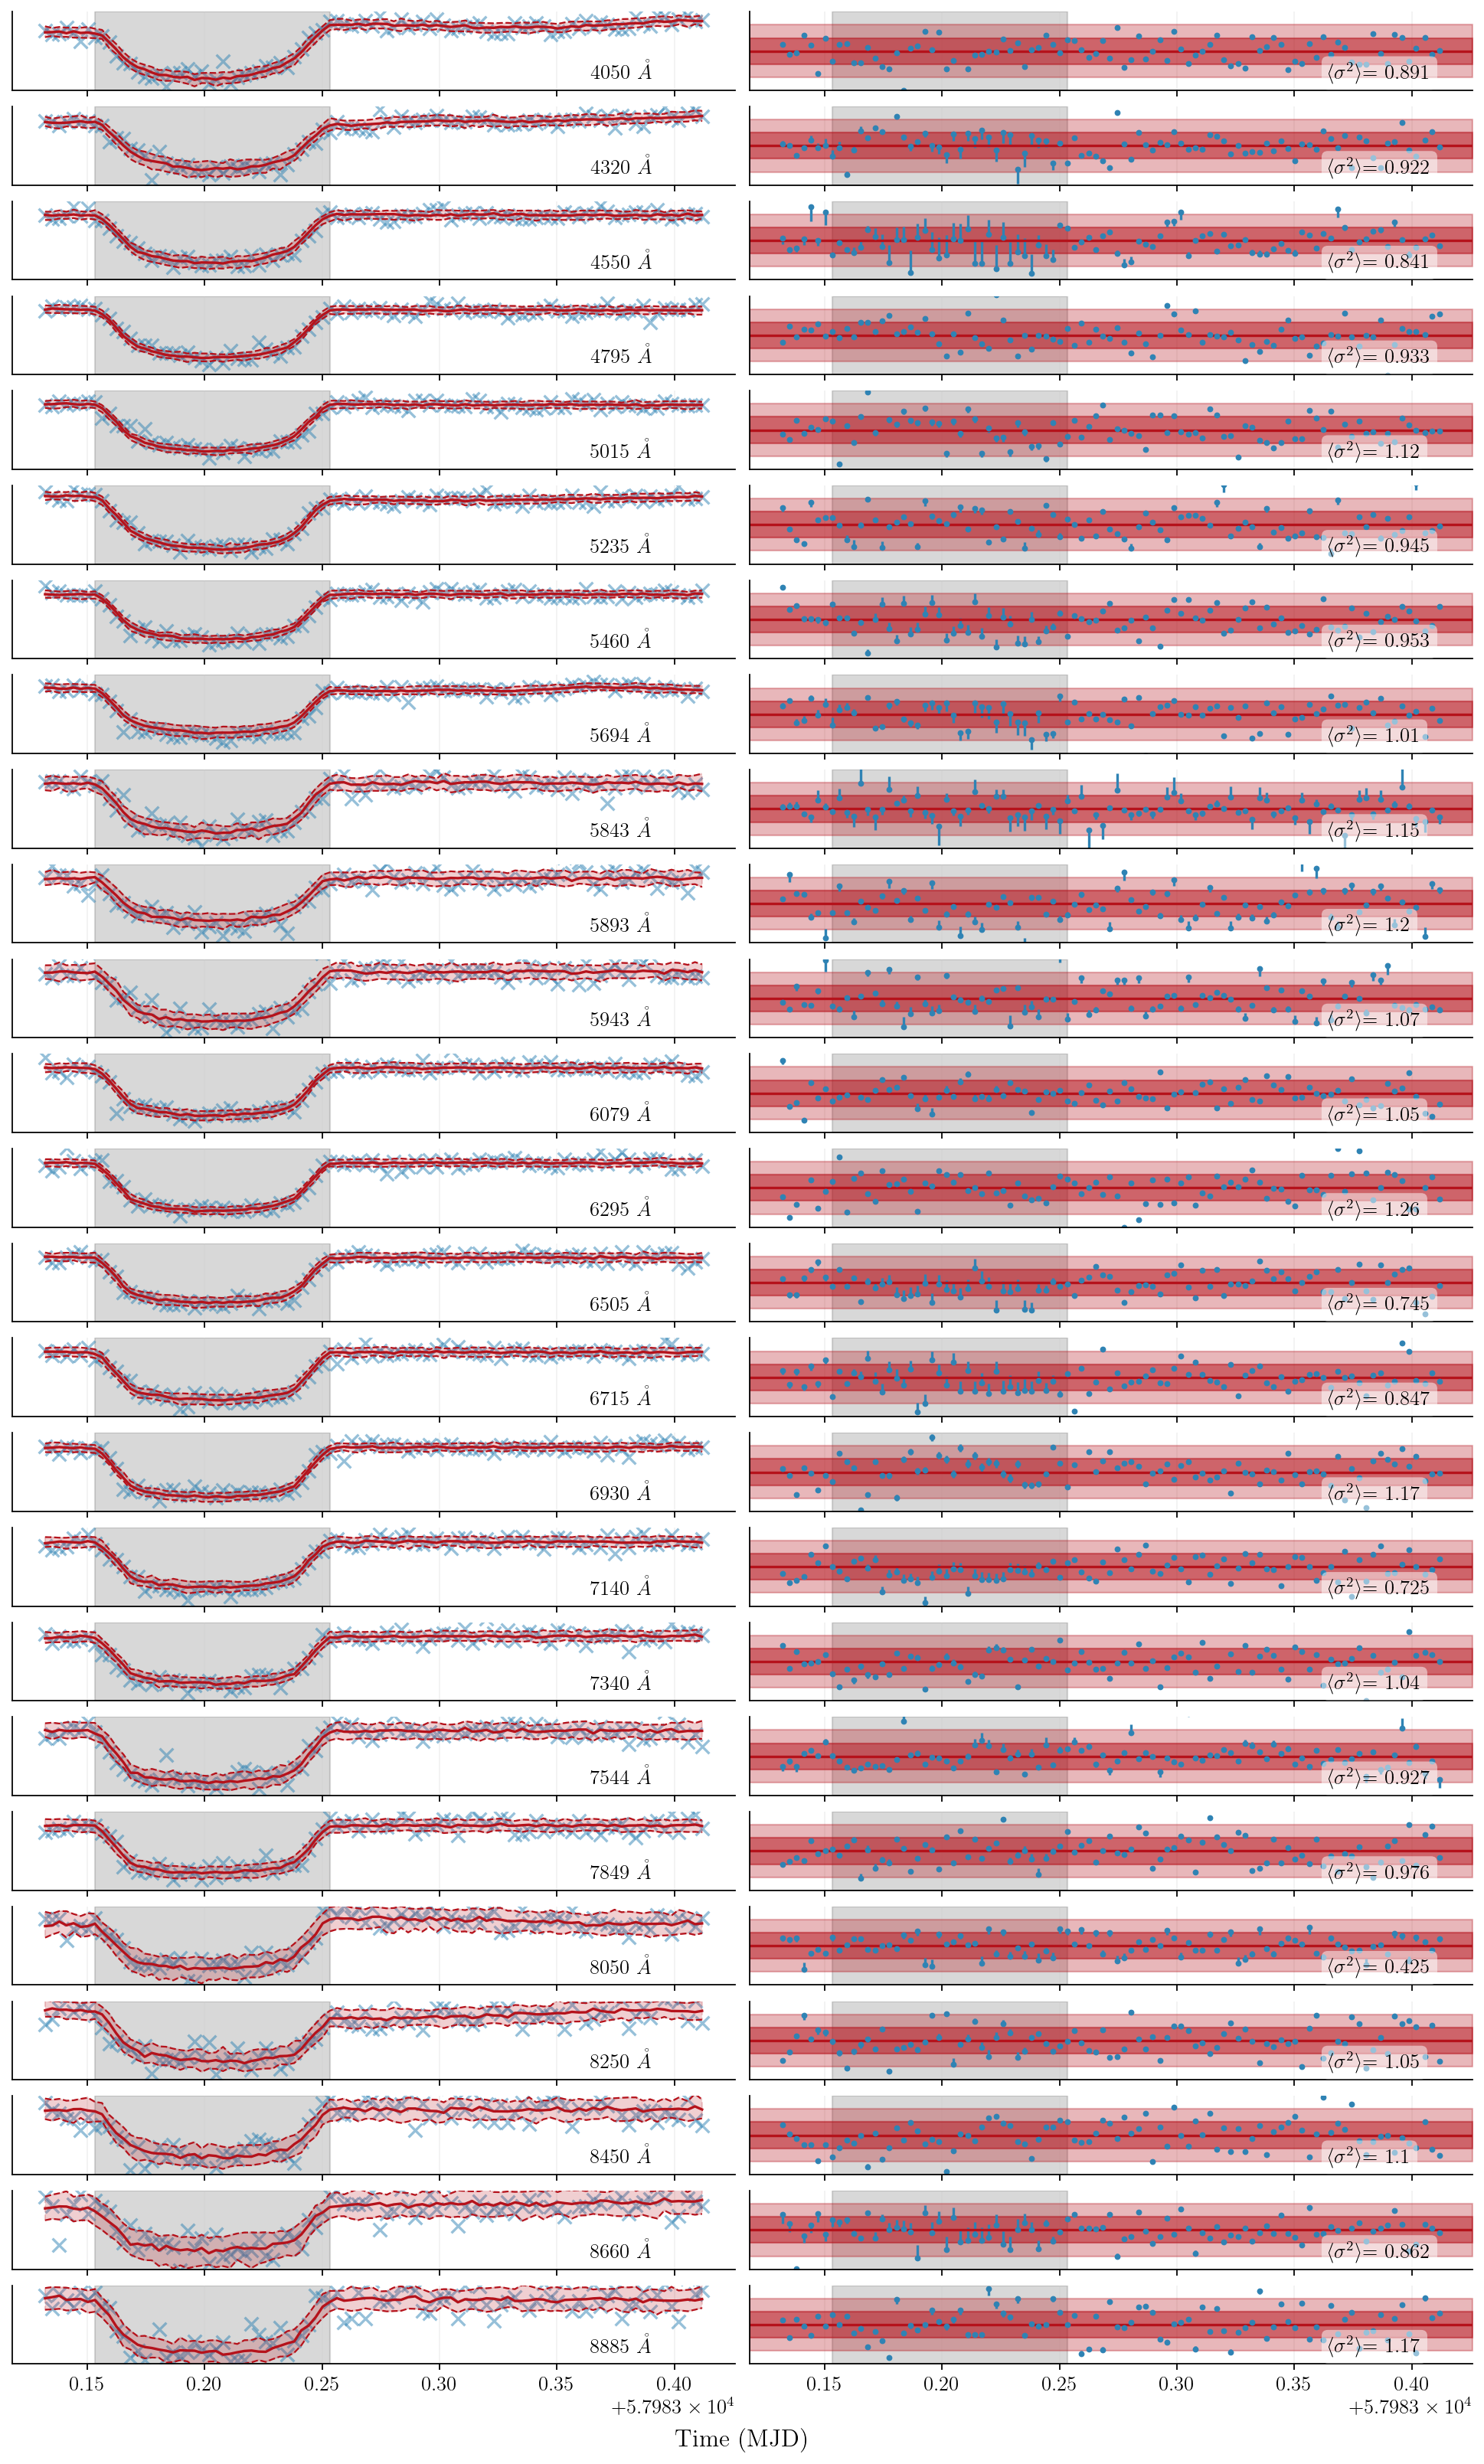

In [101]:
fig, ax = plt.subplots(
    num_datasets - 1,
    2,
    figsize=(12, 20),
    constrained_layout=False,
    sharex="col",
    sharey="col",
)
fig.subplots_adjust(hspace=0, wspace=0.01)

for i in range(1, num_datasets):
    i_ = i - 1
    t_ = t + t_min
    ax[i_, 0].scatter(
        t_,
        y[i],
        alpha=0.5,
    )
    plot_prediction(
        ax[i_, 0],
        t_,
        jnp.array(samples_with_transit[i]),
        errorbar=68,
    )
    plot_residuals(
        ax[i_, 1],
        t_,
        jnp.array(residuals[i]),
        credible_region=68,
        kws_residuals={"markersize": 5},
    )
    ax[i_, 1].set_ylim(-3, 3)
    ax[i_, 1].yaxis.set_label_position("right")
    ax[i_, 1].yaxis.tick_right()
    for j in [0, 1]:
        plot_masks(ax[i_, j], t_, jnp.array(mask))
        ax[i_, j].set_yticks([])

    for j in range(2):
        if j == 0:
            text_str = str(reference["wavelength"].iloc[i]) + r" $\mathring{A}$"
        else:
            text_str = rf"$\langle \sigma^2 \rangle$= {residuals_std[i]:.3}"

        ax[i_, j].text(
            0.8,
            0.15,
            text_str,
            transform=ax[i_, j].transAxes,
            bbox={
                "boxstyle": "round",
                "facecolor": "white",
                "alpha": 0.5,
                "edgecolor": "none",
            },
        )

    fig.supxlabel("Time (MJD)")
    fig.savefig("../figures/006_HATS46b/light_curves_and_residuals.pdf")

### ALLAN DEVIATION

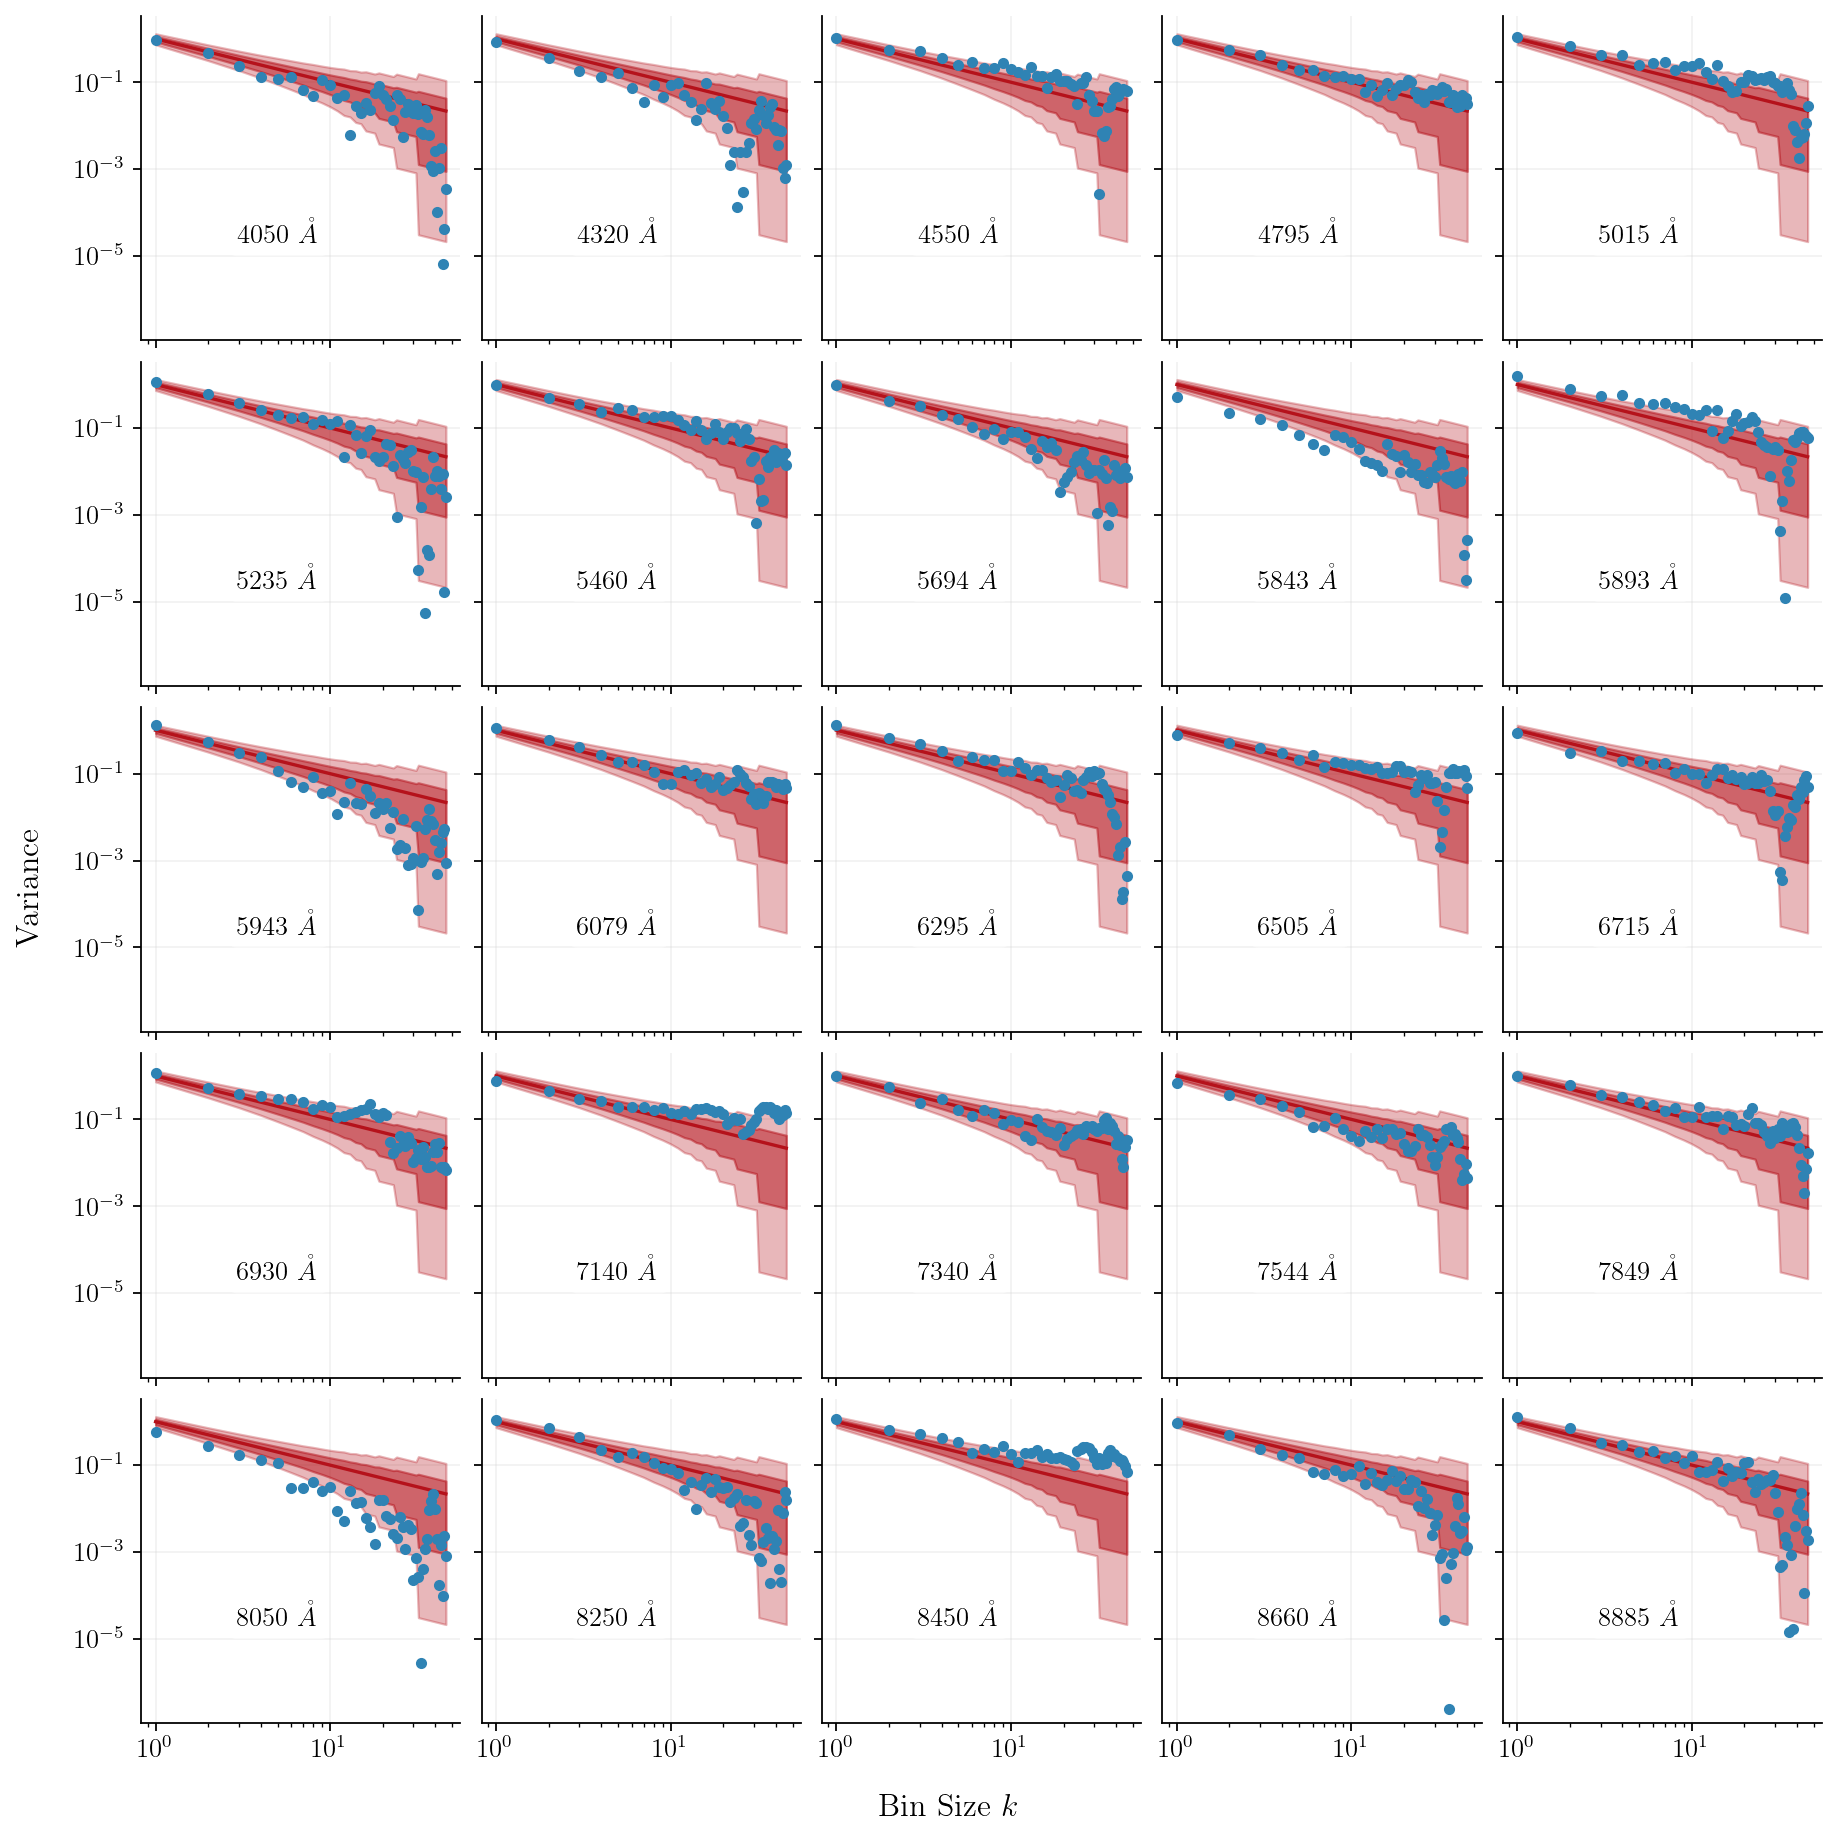

In [99]:
fig, axes = plt.subplots(
    5,
    5,
    figsize=(11, 11),
    sharex=True,
    sharey=True,
)

for i, ax in enumerate(axes.flatten()):
    plot_allan_deviation(ax, jnp.array(residuals[i + 1]))
    ax.text(
        0.3,
        0.3,
        str(reference["wavelength"].iloc[i + 1]) + r" $\mathring{A}$",
        transform=ax.transAxes,
        bbox={
            "boxstyle": "round",
            "facecolor": "white",
            "alpha": 0.5,
            "edgecolor": "none",
        },
    )

fig.supxlabel(r"Bin Size $k$", y=-0.03)
fig.supylabel("Variance", x=-0.03)
fig.savefig("../figures/006_HATS46b/allan_deviation.pdf")